# **Q1 - Zero Shot Learning Using CLIP**


* CLIP (Contrastive Language–Image Pretraining) is a pretrained model used for zero-shot image classification. It learns relationships between images and text descriptions.

*  In this task, the CLIP ViT-B/16 model is applied on the MNIST dataset containing handwritten digits from 0 to 9.

* The model performs prediction without any additional training process. Instead, it compares image features with text prompts such as "zero", "one", "two", and predicts the most similar class.

* Zero-shot learning allows the model to make predictions on a new task using previously learned knowledge.

* This experiment demonstrates how multimodal learning combines image and text information for classification.





### **Importing and Downloading Libraries**

In [11]:


import torch
import torch.nn as nn
import torch.optim as optim
import clip

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using:", device)

if device == "cuda":
    print(torch.cuda.get_device_name(0))

Using: cuda
NVIDIA GeForce GTX 1650


### **Loading  CLIP model and MNIST dataset**

In [12]:


model, preprocess = clip.load("ViT-B/16", device=device)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=preprocess
)

test_loader = DataLoader(
    mnist_test,
    batch_size=32,
    shuffle=False
)

class_names = [
    "zero","one","two","three","four",
    "five","six","seven","eight","nine"
]

text_inputs = torch.cat(
    [clip.tokenize(f"a photo of a {c}")
     for c in class_names]
).to(device)

print("Dataset Loaded:", len(mnist_test))

Dataset Loaded: 10000


### **Zero-Shot Inference**

In [13]:
all_preds=[]
all_labels=[]

with torch.no_grad():

    text_features=model.encode_text(text_inputs)

    for images,labels in test_loader:

        images=images.to(device)

        image_features=model.encode_image(images)

        similarity=(100*image_features @ text_features.T)

        preds=similarity.softmax(dim=-1).argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy=accuracy_score(
all_labels,
all_preds
)

print(f"Zero-Shot Accuracy:{accuracy*100:.2f}%")

Zero-Shot Accuracy:40.50%


### **Generating Sample Predictions**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.

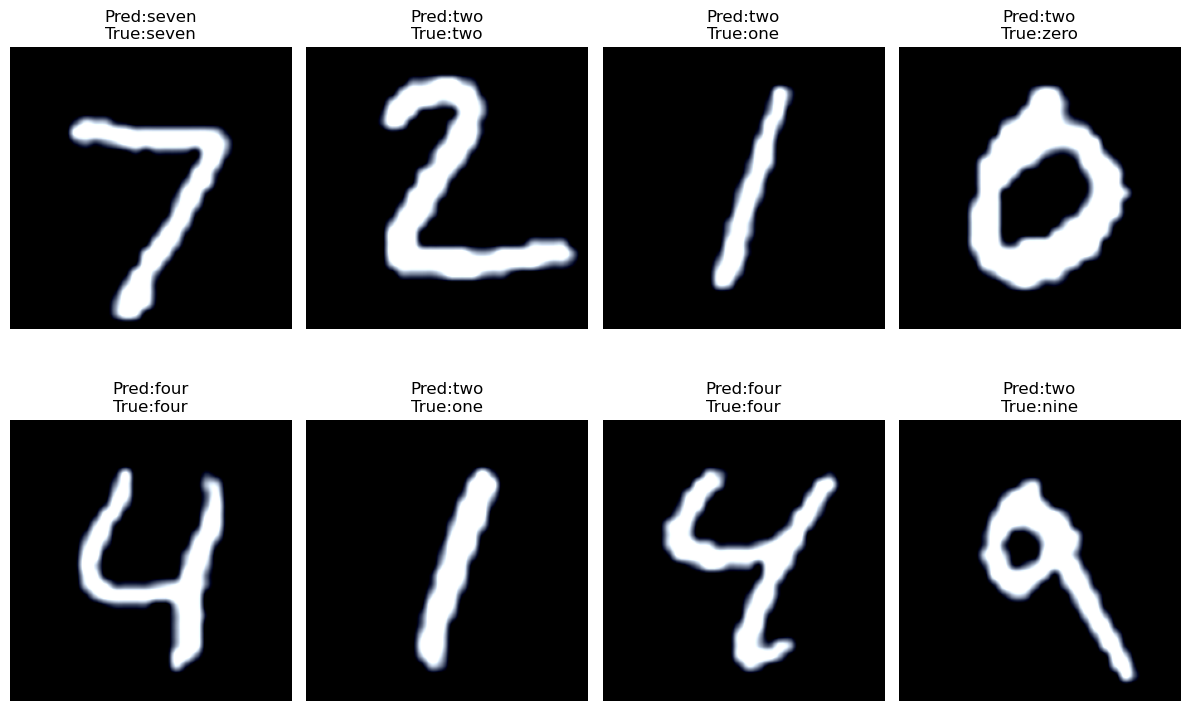

In [14]:


images, labels = next(iter(test_loader))

with torch.no_grad():
    image_features = model.encode_image(images.to(device))
    similarity = (100 * image_features @ text_features.T)
    preds = similarity.softmax(dim=-1).argmax(dim=-1)

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)

    img = images[i].cpu().permute(1,2,0)

    # reverse normalization
    img = (img * 0.5 + 0.5)

    plt.imshow(img)
    plt.title(
        f"Pred:{class_names[preds[i]]}\nTrue:{class_names[labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


## **Generating Pre Class Accuracy Bar chart**

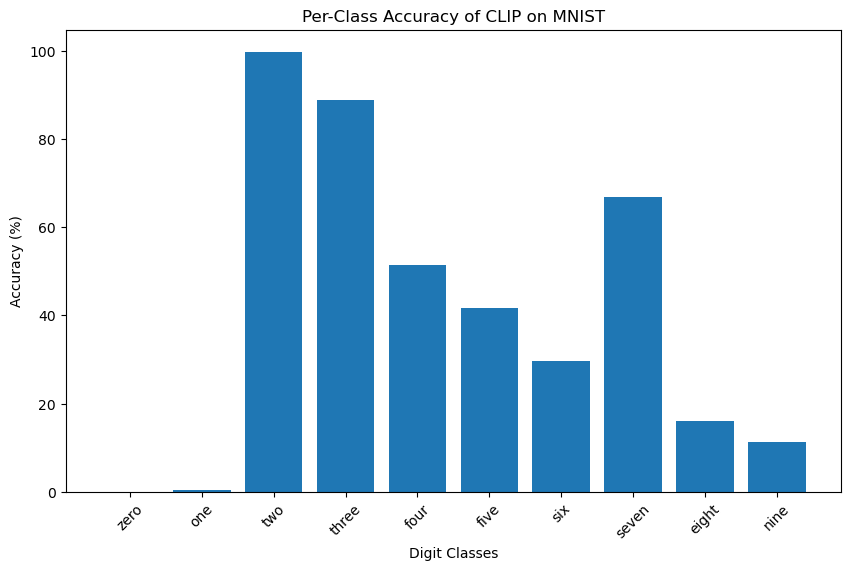

In [15]:
# Visualisation 2 - Per-Class Accuracy Bar Chart
class_accuracy = []
for i in range(10):
    total = 0
    correct = 0
    for true_label, pred_label in zip(all_labels, all_preds):
        if true_label == i:
            total += 1
            if true_label == pred_label:
                correct += 1

    acc = (correct/total)*100
    class_accuracy.append(acc)
plt.figure(figsize=(10,6))
plt.bar(
    class_names,
    class_accuracy
)
plt.xticks(rotation=45)
plt.xlabel("Digit Classes")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy of CLIP on MNIST")
plt.show()

### **Genrating Confuion Matrix**

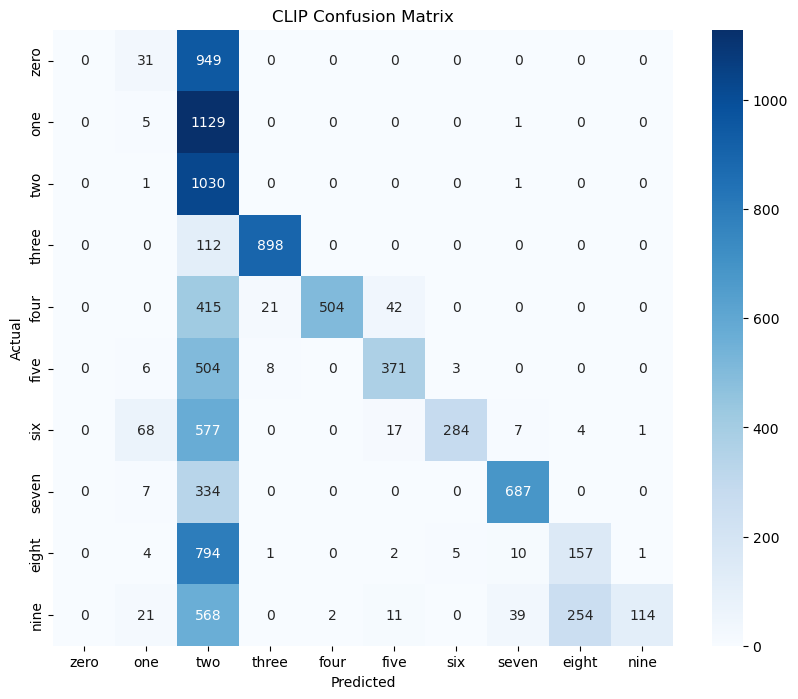

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CLIP Confusion Matrix")

plt.show()

#### **Running Zero-Shot with Vit-B/32**


In [ ]:
model_b32, preprocess_b32 = clip.load(
    "ViT-B/32",
    device=device
)
all_preds_b32 = []
all_labels_b32 = []
with torch.no_grad():
    text_features = model_b32.encode_text(text_inputs)
    for images, labels in test_loader:
        images = images.to(device)
        image_features = model_b32.encode_image(images)
        similarity = (
            100 * image_features @ text_features.T
        )
        preds = similarity.softmax(
            dim=-1
        ).argmax(dim=-1)

        all_preds_b32.extend(
            preds.cpu().numpy()
        )

        all_labels_b32.extend(
            labels.numpy()
        )
acc_b32 = accuracy_score(
    all_labels_b32,
    all_preds_b32
)
print(
    f"ViT-B/32 Zero-Shot Accuracy: {acc_b32*100:.2f}%"
)

100%|███████████████████████████████████████| 338M/338M [00:17<00:00, 20.8MiB/s]


### **Running Vit-B/16 comparison**

In [ ]:
# Run Zero-Shot with ViT-B/16 Backbone
model_b16, preprocess_b16 = clip.load(
    "ViT-B/16",
    device=device
)
all_preds_b16 = []
all_labels_b16 = []
with torch.no_grad():
    text_features = model_b16.encode_text(text_inputs)
    for images, labels in test_loader:
        images = images.to(device)
        image_features = model_b16.encode_image(images)
        similarity = (
            100 * image_features @ text_features.T
        )
        preds = similarity.softmax(
            dim=-1
        ).argmax(dim=-1)
        all_preds_b16.extend(preds.cpu().numpy())
        all_labels_b16.extend(labels.numpy())
acc_b16 = accuracy_score(
    all_labels_b16,
    all_preds_b16
)
print(f"ViT-B/16 Zero-Shot Accuracy: {acc_b16*100:.2f}%")

## **Q2- CLIP Fine-Tuning and Backbone Construction**


*   In this task, the CLIP architecture is analysed using both image and text encoders.The vision encoder extracts visual features from images, while the text encoder extracts features from class descriptions.
*   Both embeddings are projected into the same latent space using projection layers.A contrastive loss function is used so that matching image-text pairs become closer and non-matching pairs become farther apart.

*  Fine-tunig CLIP improves downstream task performance because the model adapts pretrained knowledge to the specific dataset.This improves image-text matching and feature alignment for Flickr30k.




### **Device Setup**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,),
                         (0.5,0.5,0.5))
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform)
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 163kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.8MB/s]

Number of training samples: 60000
Number of testing samples: 10000


###**Loading Pretrained VGG16**



In [ ]:
model = models.vgg16(pretrained=True)
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False
# Replacing the final classifier layer
model.classifier[6] = nn.Linear(4096, 10)
model = model.to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 104MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

###**Loss Function and Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.001)
epochs = 2

### **Training Loop**

In [ ]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/2], Loss: 0.6371
Epoch [2/2], Loss: 0.6308


##**Test Accuracy**

In [ ]:
model.eval()
correct,total = 0,0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 84.60%


##**Sample Predictions**


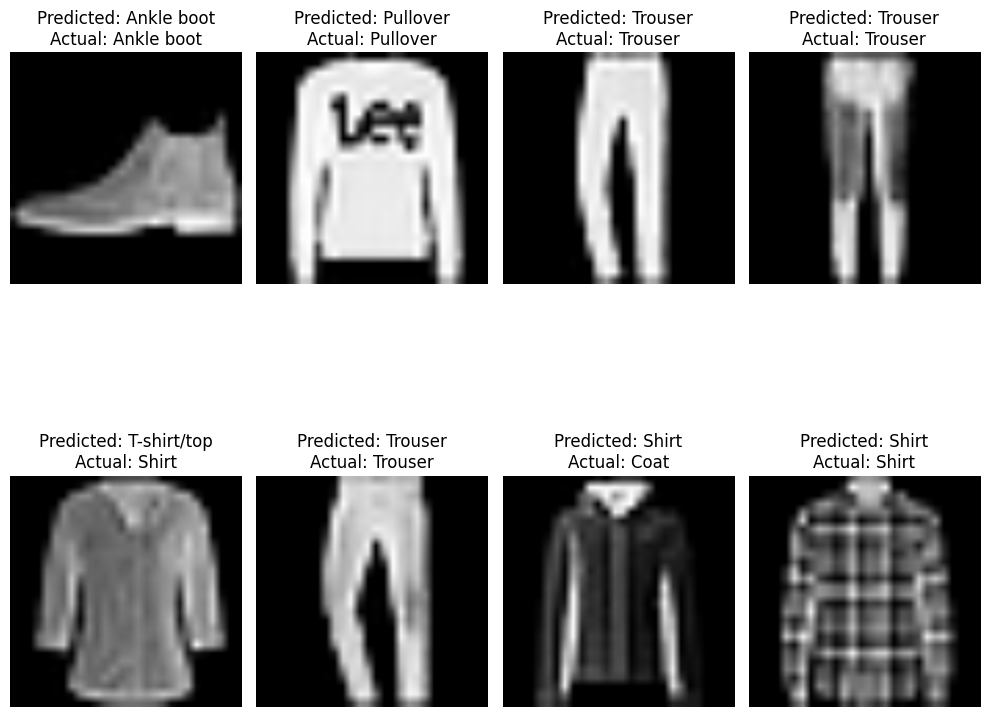

In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
model.eval()
images,labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
  outputs = model(images)
  _, predicted = torch.max(outputs, 1)
plt.figure(figsize=(10, 10))
for i in range(8):
  plt.subplot(2,4,i+1)
  img = images[i].cpu().permute(1,2,0)
  img =(img*0.5)+0.5
  plt.imshow(img)
  plt.title(f"Predicted: {classes[predicted[i]]}\nActual: {classes[labels[i]]}")
  plt.axis('off')
plt.tight_layout()
plt.show()


##**Saving the model**

In [ ]:
torch.save(model.state_dict(),"q3_vgg16_transfer_learning.pth")
print("Model Saved")

Model Saved


##**Q3-Transfer Learning Using pretrained VGG16**


*   This experiment applies transfer learning using a pretrained VGG16 model on the FashionMNIST dataset.Since VGG16 is originally trained on ImageNet, the final classification layer was replaced with a new fully connected layer containing 10 output classes for FashionMNIST.
*   All pretrained convolution layers were frozen ande only the fianl classifier layer was trained.This reduces training time and allows the model to reuse previously learned visual features
* The training losss gradually decreased during training successful learning and convergence . The model achieved a test accuracy of  84.54% which demonstrates that transfer learning is highly effective even when the source and target datasets are  different.
* Sample predictions show that the model correctly identifies most clothing categories, although visually simialr clases such as Shirt and T shirt may occasionally create confusion.
* Overall transfer learning with pretrained VGG16 provides faster convergence and strong performace compared to training a deep network from scratch.



#**Q4-VGG16 Trainng**

This section trains VGG16 from scratch on the Fashion MNIST dataset without using pretrained Image Net weights.The purrpose is to compare the perfomance of training from scracth versus transfer learning and evaluate the benefits of pretrained feature extraction

In [ ]:
model_scratch  =models.vgg16(pretrained =False)

#Replacing final Layer for 10 classes
model_scratch.classifier[6] = nn.Linear(
    model_scratch.classifier[6].in_features, 10
)
model_scratch = model_scratch.to(device)
print(model_scratch)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

##**Optimizer Cell**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)
epochs = 2

##**Training Loop**

In [ ]:
for epoch in range(epochs):
    model_scratch.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_scratch.zero_grad()

        outputs = model_scratch(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_scratch.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/2], Loss: 2.3194
Epoch [2/2], Loss: 2.3029


##**Test Accuracy**

In [ ]:
model_scratch.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_scratch(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 10.00%


In [ ]:
torch.save(model_scratch.state_dict(),"q4_vgg16_scratch.pth")
print("Model Saved")

Model Saved


##**Q4 - Analysis and Comaprison**

 * In this experiment VGG16 was trained from scratch without using pretrained ImageNet weights.Unlike transfer learning all parameters were initialized randomly and trained entirely on th FashionMNIST dataset .

 * The training loss remained high and the final tesst accuracy was only 10.00% which is significantly lower than the pretrained VGG16 model used in Q3(84.54%).

 * This happened becasue training a very deep network like VGG16 from scracth requires a much larger dataset and longer training time.With only a smaller number of epochs and limited computational resources the model was unable to learn strong feature representations.

 * This comparison clearly demonstrates the importance of transfer learning.Pretrained models provide better feature extraction faster convergence and much stronger performance when working with the limited datasets such as Fashion MNIST.

 * Overall transfer learning is far more effective than training from scratch in this scenario.




##**Q5 -Comparison Between Transfer Learning and Training From Scratch**


*   In Q3, tranfer learning was applied using  a pretrained VGG16  model that was originally trained in ImageNet.Only the final classification layer was replaced and trained for FashionMINIST classfication , while the earlier convolutional layers were the earliear convolution layers were frozen.

*   The model achieved a test accuracy of 84.60% showing strong perfomance even with  only a small number of training epochs.This demonstrates that pretrained models can effectively transfer leared visual features to new tasks.

*  In Q4,VGG16 was trained entirely from scratch without using pretrained weights.All parameters were intitalized randomly and trained using the FashionMNIST dataset.

* The model achieved only 10.00% test accuracy after 2 epochs, which is significantly lower than the transfer learning approcah.This happened because deep models like VGG16 require large datasets and longer training time to learn useful features from scracth.

* The comaprison clearly shows that transfer learning provides better accurracy faster convergence , and lower computational cost compared to training from scratch.

* Therefore, pretrained  models are generally the pretrained approach when working with limited  data and limited computational resources.




#**Q6 - Gnerative Adversarial Network (GAN)**
This section implements a basic GAN modelfor image generation using the FashionMNIST dataset.The goal is to train a Generator creates fake FashionMNIST images ans the Discriminator learns to distinguish between real and fake images.This helps demonstrate generative learning and compress with previous discriminative models such as VGG16

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.utils import save_image


##**New GAN Transform**


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

##**GAN Dataset**

In [ ]:
train_dataset_gan = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_gan
)

train_loader_gan = DataLoader(
    train_dataset_gan,
    batch_size=64,
    shuffle=True
)

print("GAN Training Samples:", len(train_dataset_gan))

GAN Training Samples: 60000


##**Generator  Model**

In [ ]:
class Gnerator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(100,256),
        nn.ReLU(),
        nn.Linear(256,512),
        nn.ReLU(),
        nn.Linear(512,1024),
        nn.ReLU(),
        nn.Linear(1024,28*28),
        nn.Tanh()
    )
  def forward(self,z):
    img = self.model(z)
    img = img.view(img.size(0),1,28,28)
    return img


##**Discriminator Model**

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

##**Creating Generator and Discriminator Objects**


In [ ]:
generator = Gnerator().to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Gnerator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


##**Loss Function and Optimizer**

In [ ]:
adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002
)
optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)
epochs = 2
latent_dim = 100

##**GAN Training Loop**

In [ ]:
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(train_loader_gan):

        real_imgs = imgs.to(device)

        valid = torch.ones(imgs.size(0), 1).to(device)
        fake = torch.zeros(imgs.size(0), 1).to(device)

        # Train Generator
        optimizer_G.zero_grad()

        z = torch.randn(imgs.size(0), latent_dim).to(device)
        generated_imgs = generator(z)

        g_loss = adversarial_loss(
            discriminator(generated_imgs),
            valid
        )

        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        optimizer_D.zero_grad()

        real_loss = adversarial_loss(
            discriminator(real_imgs),
            valid
        )

        fake_loss = adversarial_loss(
            discriminator(generated_imgs.detach()),
            fake
        )

        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [1/2] | D Loss: 0.0189 | G Loss: 3.8028
Epoch [2/2] | D Loss: 0.0263 | G Loss: 4.7597


##**Generating Final Fake Images**

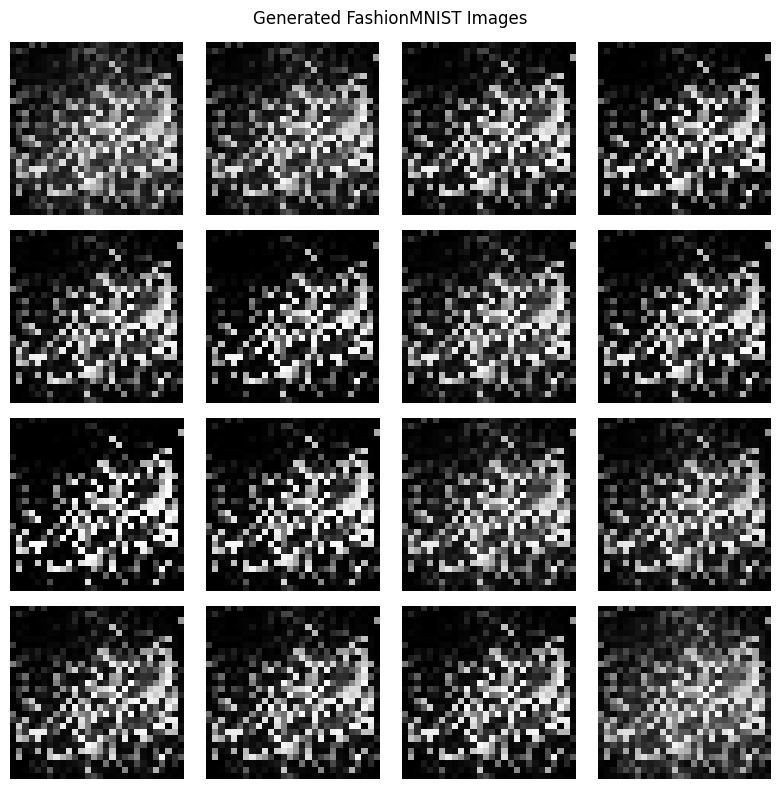

In [ ]:
generator.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated_images = generator(z)

plt.figure(figsize=(8,8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    img = generated_images[i].cpu().squeeze()
    plt.imshow(img, cmap='gray')
    plt.axis("off")

plt.suptitle("Generated FashionMNIST Images")
plt.tight_layout()
plt.show()

##**Saving Generator Model**

In [ ]:
torch.save(generator.state_dict(), "q6_generator_gan.pth")
print("GAN Generator saved successfully")

GAN Generator saved successfully


##**Q6-Analysis and Discussion**


*   In this experiment a Generative Adversarial Network(GAN) was implemented using the MINIST dataset for image generation.The
*   The Generator learns to create fake FashionMinist images from randomn noise vectors,while the Discriminator learns to distinguish between real and fake images.During training, both models compete against each other,which improves quality of generated  images over time.

* The Discriminator loss remained low while the Generator loss gradually changed, showing that adversarial training was sucessfully taking place.

* The generated images are still noisy becasue the model was trained for only 2 epochs due to limited computational resources  amd time constraints .With more training epochs and better tuning, the Generator would produce clearer and more realistic FashionMNISY images.


##**Q7- Masked Self-Attention in GPT2**



*   GPT2(Generative Pre-Trained Transformer 2) is an autoregressive language model that predicts the next word in a sequence based on previous words.One of its most important components is the masked self-attention mechanism.
*   Self-attention allows each word(token) in a sentence to look at other words and understand contextual relationships.For example in the sentence "The cat sat because it was tired",the model learns that "it " refers to "cat".
* In GPT2 masked self-attention is used instead of normal self-attention.The masking ensures that each token can only attend to previous tokens and not future tokens.This is important because GPT2 generates text from left to right and should not see the future during prediction.
* For example, when predicting the word "beautiful" in the sentence "The weather is beautidul today",GPT2 can use "The weather is " but cannot look at "today" before predictions.
* This masking is implemented using a triangular attention mask that blocks access to future positions in the sequence.
* This mechanism is powerful for NLP because it preserves the casual structure of language generation and it helps the model to learn long range dependencies between words and improves text generation quality by maintaining context and it also allows parallel training while still preserving sequential predictions.





##**Q8-BERT Pretraining**
BERT(Bidirectional Encoder Representations from Transformers) is a transformer based language  mopdel developed by Google for Natural Language Processing tasks.Unlike traditional language models that process text only from left to right, BERT reads text bidirectionally, meaning it understands context from both directions simultaneously.

BERT is pretrained using two important Objectives:
### 1.**Masked Language Modeling(MLM)**
In Masked Language Modeling, some words in a sentence are randomly masked and the model learns to predict the missing words using surrounding context.

For Ex:

Input:
"The cat sat on the [MASK]"

Target:
"mat"

This helps BERT learns deep contextual understanding of language because it uses both left and right context infromation.

### 2. **Next Sentence Predictions(NSP)**
In Next Sentence Prediction,BERT receives two sentences and predicts whether the second sentence logically  folows the first sentence.

Example:

Sentence A:
"I went to the store"
Sentence B:
"I bought some milk"

Prediction:
True

This task helps BERT understand sentence relationships and improves performance on tasks such as question answering and natural language inference.

The advantages of BERT predicting include:
1. Better contextual understanding of language.
2. Improved performance on downstream NLP tasks.
3. Strong bidirectional feature learning.
4. Efficient transfer learning through fine tuning.

Compared to traditional NLP methods, BERT achieves much higher accuracy because it captures semantic meaning and contextual relationships more effectively.

Therefore, BERT pretraining plays a major role in modern Natural Language Processing systems such as chatbots, search engines, sentiment analysis, and question answering applications.











## **Q9- Fine tuning Mechanism in CLIP**


*   CLIP (Contrastive Language-Image Pretraining) can be fine tuned for downstram tasks by  adapting pretrained image and text encoders to a specific dataset.During fine tuning, the model uses image-text pairs and learns stronger relationships between visual and textual representations.

*   The image encoder extracts visual features from images while the text encoder extracts semantic information from text descriptions.Both outputs are projected into a shared embedding space.

*  A contrastive loss function is used during training so that matching image-text pairs move closer together while non-matching pairs move further apart. This improves the model's ability to correctly associate images with relevant text descriptions.

* Fine-tuning helps the model adapt pretrained knowledge to a target dataset and improves classification accuracy, retrieval performance, and feature alignment. Compared to training from scratch, fine-tuning requires less data and computational resources while achieving better performance.






##**References**


1.   PyTorch Documentation – https://pytorch.org/docs/stable/index.html
2.   Torchvision Documentation – https://pytorch.org/vision/stable/index.html
3. Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition.
4. FashionMNIST Dataset – https://github.com/zalandoresearch/fashion-mnist
5. Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition.
6. Radford, A. et al. (2021). Learning Transferable Visual Models From Natural Language Supervision (CLIP).



##**AI Use Statement**


*   I ued AI tools for brainstorming assignment structre, understanding deep learning
*   I also used it to better understand transfer learning, GAN implementation and CLIP concepts. All final coding,execution,screenshots and submision decisions were completed and verified by me


